# Density channel layout：dense mask 的成本与 packed 参考

这个 notebook 测量 BrainCell 当前 density channel 的全 point-space dense layout，并用现有 `Na_HH1952`、`K_HH1952`、`IL` 和积分器构造一个 synthetic packed 对照。packed 对照不修改 runtime，只用于估算 gather → compact update → scatter-add 的收益和代价。

所有 wall time 都在独立 CPU 子进程中测量；前两个调用丢弃，随后取 7 次中位数。编译器指标来自 JAX/XLA 的 `cost_analysis()`、`memory_analysis()` 和 optimized HLO。

In [1]:
import json
import os
from pathlib import Path
import subprocess
import sys

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

candidates = [
    Path.cwd() / "channel_layout_benchmark.py",
    Path.cwd() / "examples" / "multi_compartment" / "channel_layout_benchmark.py",
]
BENCHMARK = next((path.resolve() for path in candidates if path.exists()), None)
if BENCHMARK is None:
    raise FileNotFoundError("Cannot locate channel_layout_benchmark.py")
sys.path.insert(0, str(BENCHMARK.parent))
import channel_layout_benchmark as bench

def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    rule = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row[column]) for column in columns) + " |" for row in rows]
    display(Markdown("\n".join([header, rule, *body])))

def mib(value):
    return value / 1024**2

def isolated_case(*args):
    env = os.environ.copy()
    env["JAX_PLATFORMS"] = "cpu"
    completed = subprocess.run(
        [sys.executable, str(BENCHMARK), *map(str, args)],
        check=True, capture_output=True, text=True, env=env,
    )
    return json.loads(completed.stdout.strip().splitlines()[-1])

environment = bench.environment_summary()
environment

{'python': '3.11.15',
 'python_executable': '/home/swl/anaconda3/envs/braincell_311/bin/python',
 'jax': '0.10.1',
 'backend': 'cpu',
 'devices': ['cpu:0'],
 'precision': 32,
 'x64_enabled': False}

## 1. 固定 100-CV 模型

模型包含 soma、两个 dendrite 和一个 axon，CV 数分别为 `(4, 32, 32, 32)`。代表性 mixed layout 是：HHNa 仅 soma、HHK 覆盖第一个 dendrite 的近端一半、leak 覆盖第二个 dendrite。

In [2]:
fixture = bench.build_cell(pop_size=1, profile="mixed")
layout_rows = bench.channel_layout_rows(fixture)
print(f"n_cv={fixture.n_cv}, n_point={fixture.n_point}, population shape={fixture.pop_size}")
markdown_table(
    [{
        "channel": row["name"],
        "active": row["n_active"],
        "active / n_cv": f"{row['active_fraction_cv']:.1%}",
        "runtime shape": row["node_shape"],
        "gate shapes": row["gate_shapes"],
    } for row in layout_rows],
    ["channel", "active", "active / n_cv", "runtime shape", "gate shapes"],
)

n_cv=100, n_point=105, population shape=(1,)


| channel | active | active / n_cv | runtime shape | gate shapes |
| --- | --- | --- | --- | --- |
| na | 4 | 4.0% | (1, 105) | {'p': (1, 105), 'q': (1, 105)} |
| k | 16 | 16.0% | (1, 105) | {'p': (1, 105)} |
| leak | 32 | 32.0% | (1, 105) | {} |

## 2. 持久数组内存

这里分别统计 declaration buffers、runtime 参数、gate value 以及 mask/index。它不是进程 RSS 或 GPU allocator 占用；XLA constants 和临时值在后面的 compiler memory 中单列。`packed` 保留实际 dtype，只把尾维从 `n_point` 换成 `n_active`；`hybrid` 对每个 channel 选择 dense/packed 中较小者。

In [3]:
memory_population = []
for pop_size in bench.POP_SIZES:
    cell = bench.build_cell(pop_size=pop_size, profile="mixed")
    summary = bench.memory_summary(cell)
    memory_population.append({
        "pop_size": pop_size,
        "dense MiB": f"{mib(summary['dense_total_bytes']):.4f}",
        "packed MiB": f"{mib(summary['projected_packed_total_bytes']):.4f}",
        "hybrid MiB": f"{mib(summary['projected_hybrid_total_bytes']):.4f}",
        "hybrid saved": f"{summary['projected_hybrid_saved_fraction']:.1%}",
    })
markdown_table(memory_population, list(memory_population[0]))

| pop_size | dense MiB | packed MiB | hybrid MiB | hybrid saved |
| --- | --- | --- | --- | --- |
| 1 | 0.0079 | 0.0016 | 0.0016 | 80.1% |
| 10 | 0.0764 | 0.0139 | 0.0139 | 81.8% |
| 100 | 0.7613 | 0.1375 | 0.1375 | 81.9% |
| 1000 | 7.6106 | 1.3735 | 1.3735 | 82.0% |

In [4]:
coverage_memory = []
for profile in ("soma", "half_dend", "one_dend", "mixed", "global"):
    cell = bench.build_cell(pop_size=1000, profile=profile)
    summary = bench.memory_summary(cell)
    coverage_memory.append({
        "profile": profile,
        "active counts": [row["n_active"] for row in summary["rows"]],
        "dense MiB": f"{mib(summary['dense_total_bytes']):.3f}",
        "packed MiB": f"{mib(summary['projected_packed_total_bytes']):.3f}",
        "hybrid choice": [row["hybrid_layout_choice"] for row in summary["rows"]],
        "hybrid saved": f"{summary['projected_hybrid_saved_fraction']:.1%}",
    })
markdown_table(coverage_memory, list(coverage_memory[0]))

| profile | active counts | dense MiB | packed MiB | hybrid choice | hybrid saved |
| --- | --- | --- | --- | --- | --- |
| soma | [4, 4, 4] | 7.611 | 0.290 | ['packed', 'packed', 'packed'] | 96.2% |
| half_dend | [16, 16, 16] | 7.611 | 1.160 | ['packed', 'packed', 'packed'] | 84.8% |
| one_dend | [32, 32, 32] | 7.611 | 2.320 | ['packed', 'packed', 'packed'] | 69.5% |
| mixed | [4, 16, 32] | 7.611 | 1.373 | ['packed', 'packed', 'packed'] | 82.0% |
| global | [100, 100, 100] | 7.611 | 7.249 | ['packed', 'packed', 'packed'] | 4.8% |

## 3. 当前 full-cell HLO：coverage 是否减少工作量？

下面比较 mixed `[4, 16, 32]` 与 global `[100, 100, 100]`。两者使用相同 population 和 timestep 数；如果 mask 真正跳过计算，compiler cost 应随 coverage 改变。

In [5]:
current_compiler = {}
for profile in ("mixed", "global"):
    current_compiler[profile] = isolated_case(
        "--mode", "current", "--profile", profile, "--pop-size", 1,
        "--steps", 10, "--discard", 0, "--repeats", 1, "--compiler-analysis",
    )
compiler_rows = []
for profile, result in current_compiler.items():
    cost = result["compiler"]["cost"]
    memory = result["compiler"]["memory"]
    hlo = result["compiler"]["hlo"]
    compiler_rows.append({
        "profile": profile,
        "active": result["active_counts"],
        "FLOPs": int(cost["flops"]),
        "transcendentals": int(cost["transcendentals"]),
        "bytes accessed": int(cost["bytes accessed"]),
        "temp bytes": memory["temp_size_in_bytes"],
        "fusion instructions": hlo["fusion_instructions"],
    })
markdown_table(compiler_rows, list(compiler_rows[0]))
assert current_compiler["mixed"]["compiler"]["cost"] == current_compiler["global"]["compiler"]["cost"]

| profile | active | FLOPs | transcendentals | bytes accessed | temp bytes | fusion instructions |
| --- | --- | --- | --- | --- | --- | --- |
| mixed | [4, 16, 32] | 27378 | 945 | 409720 | 3320 | 16 |
| global | [100, 100, 100] | 27378 | 945 | 409720 | 3320 | 16 |

XLA 确实把大量逐元素表达式融合成 fusion，但 fusion 的作用是减少 kernel/中间数组开销，不是让 inactive lane 不执行。localized/global 的 compiler cost 完全相同，是比单看 fusion 数量更直接的证据。

## 4. 当前 full-cell CPU timing

每次调用运行 100 steps（`dt=0.025 ms`）。这些数字包含 cable solve、ions、channels 和 probe；它们用于 population scaling 和 localized/global 相对比较，不代表 GPU 性能。

In [6]:
current_timings = []
for pop_size in bench.POP_SIZES:
    result = isolated_case(
        "--mode", "current", "--profile", "mixed", "--pop-size", pop_size,
        "--steps", 100, "--discard", 2, "--repeats", 7,
    )
    current_timings.append({
        "profile": "mixed", "pop_size": pop_size,
        "median ms": 1000 * result["timing"]["median_s"],
        "min ms": 1000 * result["timing"]["min_s"],
        "max ms": 1000 * result["timing"]["max_s"],
    })
global_1000 = isolated_case(
    "--mode", "current", "--profile", "global", "--pop-size", 1000,
    "--steps", 100, "--discard", 2, "--repeats", 7,
)
current_timings.append({
    "profile": "global", "pop_size": 1000,
    "median ms": 1000 * global_1000["timing"]["median_s"],
    "min ms": 1000 * global_1000["timing"]["min_s"],
    "max ms": 1000 * global_1000["timing"]["max_s"],
})
markdown_table(
    [{**row, "median ms": f"{row['median ms']:.2f}", "min ms": f"{row['min ms']:.2f}", "max ms": f"{row['max ms']:.2f}"} for row in current_timings],
    list(current_timings[0]),
)

| profile | pop_size | median ms | min ms | max ms |
| --- | --- | --- | --- | --- |
| mixed | 1 | 7.13 | 6.72 | 7.85 |
| mixed | 10 | 17.00 | 12.12 | 24.16 |
| mixed | 100 | 174.33 | 173.26 | 175.61 |
| mixed | 1000 | 980.85 | 971.72 | 989.25 |
| global | 1000 | 1003.63 | 980.07 | 1012.65 |

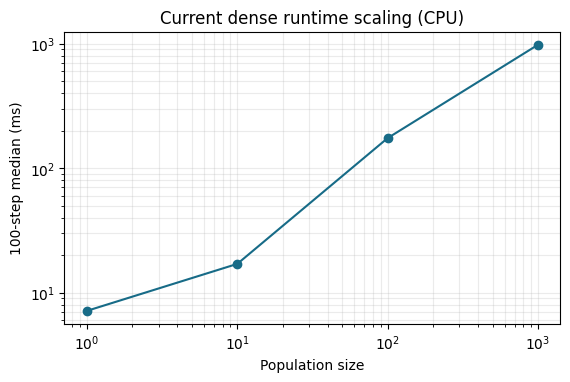

In [7]:
mixed_rows = [row for row in current_timings if row["profile"] == "mixed"]
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot([row["pop_size"] for row in mixed_rows], [row["median ms"] for row in mixed_rows], marker="o", color="#176B87")
ax.set(xscale="log", yscale="log", xlabel="Population size", ylabel="100-step median (ms)", title="Current dense runtime scaling (CPU)")
ax.grid(True, which="both", alpha=0.25)
plt.show()

## 5. Synthetic packed reference

packed 路径使用静态 point indices gather 电压和 ion info，只更新 active HH gates，然后把三种 current scatter-add 回 105-point 空间。它调用仓库现有 channel 类和 `ind_exp_euler_step`，没有重写 HH 方程。

In [8]:
parity = bench.micro_parity(pop_size=2, profile="mixed", steps=3)
display(parity)
assert parity["max_gate_error"] < 1e-6
assert parity["max_current_error"] < 1e-3

{'max_current_error': 0.000244140625, 'max_gate_error': 0.0}

In [9]:
micro_costs = []
for profile in ("soma", "half_dend", "one_dend", "global"):
    for layout in ("dense", "packed"):
        result = isolated_case(
            "--mode", "micro", "--layout", layout, "--profile", profile,
            "--pop-size", 1, "--steps", 10, "--discard", 2, "--repeats", 3,
        )
        cost = result["compiler"]["cost"]
        micro_costs.append({
            "profile": profile, "layout": layout, "active": result["active_counts"][0],
            "FLOPs": int(cost["flops"]), "transcendentals": int(cost["transcendentals"]),
            "bytes accessed": int(cost["bytes accessed"]),
            "temp bytes": result["compiler"]["memory"]["temp_size_in_bytes"],
        })
markdown_table(micro_costs, list(micro_costs[0]))

| profile | layout | active | FLOPs | transcendentals | bytes accessed | temp bytes |
| --- | --- | --- | --- | --- | --- | --- |
| soma | dense | 4 | 14072 | 945 | 189394 | 9412 |
| soma | packed | 4 | 598 | 36 | 17238 | 5384 |
| half_dend | dense | 16 | 14072 | 945 | 189394 | 9412 |
| half_dend | packed | 16 | 2386 | 144 | 41610 | 5384 |
| one_dend | dense | 32 | 14072 | 945 | 189394 | 9412 |
| one_dend | packed | 32 | 4770 | 288 | 74106 | 6280 |
| global | dense | 100 | 14072 | 945 | 189394 | 9412 |
| global | packed | 100 | 14902 | 900 | 212214 | 10760 |

In [10]:
micro_timings = []
for pop_size in bench.POP_SIZES:
    for layout in ("dense", "packed"):
        result = isolated_case(
            "--mode", "micro", "--layout", layout, "--profile", "mixed",
            "--pop-size", pop_size, "--steps", 100, "--discard", 2, "--repeats", 7,
        )
        micro_timings.append({
            "layout": layout, "pop_size": pop_size,
            "median ms": 1000 * result["timing"]["median_s"],
            "FLOPs": int(result["compiler"]["cost"]["flops"]),
            "transcendentals": int(result["compiler"]["cost"]["transcendentals"]),
        })
markdown_table(
    [{**row, "median ms": f"{row['median ms']:.3f}"} for row in micro_timings],
    list(micro_timings[0]),
)

| layout | pop_size | median ms | FLOPs | transcendentals |
| --- | --- | --- | --- | --- |
| dense | 1 | 0.476 | 14072 | 945 |
| packed | 1 | 0.511 | 1470 | 72 |
| dense | 10 | 0.990 | 140702 | 9450 |
| packed | 10 | 0.623 | 12450 | 720 |
| dense | 100 | 5.535 | 1407002 | 94500 |
| packed | 100 | 4.185 | 122250 | 7200 |
| dense | 1000 | 63.740 | 14070002 | 945000 |
| packed | 1000 | 45.784 | 1220250 | 72000 |

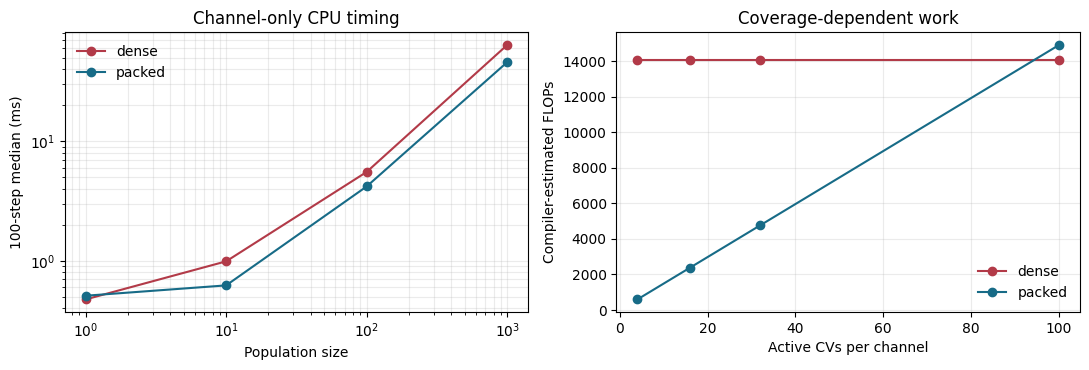

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
colors = {"dense": "#B23A48", "packed": "#176B87"}
for layout in ("dense", "packed"):
    rows = [row for row in micro_timings if row["layout"] == layout]
    axes[0].plot([row["pop_size"] for row in rows], [row["median ms"] for row in rows], marker="o", label=layout, color=colors[layout])
coverage_rows = {layout: [row for row in micro_costs if row["layout"] == layout] for layout in ("dense", "packed")}
for layout, rows in coverage_rows.items():
    axes[1].plot([row["active"] for row in rows], [row["FLOPs"] for row in rows], marker="o", label=layout, color=colors[layout])
axes[0].set(xscale="log", yscale="log", xlabel="Population size", ylabel="100-step median (ms)", title="Channel-only CPU timing")
axes[1].set(xlabel="Active CVs per channel", ylabel="Compiler-estimated FLOPs", title="Coverage-dependent work")
for ax in axes:
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [12]:
mixed_memory_1000 = bench.memory_summary(bench.build_cell(pop_size=1000, profile="mixed"))
dense_micro_1000 = next(row for row in micro_timings if row["layout"] == "dense" and row["pop_size"] == 1000)
packed_micro_1000 = next(row for row in micro_timings if row["layout"] == "packed" and row["pop_size"] == 1000)
memory_saved = mixed_memory_1000["projected_hybrid_saved_fraction"]
flop_reduction = 1.0 - packed_micro_1000["FLOPs"] / dense_micro_1000["FLOPs"]
micro_speedup = dense_micro_1000["median ms"] / packed_micro_1000["median ms"]
display(Markdown(
    f"**本机结果摘要：** mixed coverage、pop=1000 时，hybrid persistent-array 投影节省 "
    f"**{memory_saved:.1%}**；packed microkernel 的 compiler FLOPs 减少 **{flop_reduction:.1%}**，"
    f"100-step CPU 中位耗时获得 **{micro_speedup:.2f}x** speedup。pop=1 时 packed 反而更慢，"
    "说明 gather/scatter 固定成本必须进入 layout 决策。"
))

**本机结果摘要：** mixed coverage、pop=1000 时，hybrid persistent-array 投影节省 **82.0%**；packed microkernel 的 compiler FLOPs 减少 **91.3%**，100-step CPU 中位耗时获得 **1.39x** speedup。pop=1 时 packed 反而更慢，说明 gather/scatter 固定成本必须进入 layout 决策。

## 6. 结论与建议

1. **当前 mask 没有减少门控计算。** full-cell localized/global 的 compiler cost 相同；XLA fusion 减少 kernel 和中间数组，但不会跳过 inactive lanes。
2. **只把 inactive derivative 设为零不够。** 它能冻结无效 gate，却通常仍会先计算 `alpha/beta` 或 `inf/tau`。
3. **仅从 point-space 改到 CV-space 收益有限。** 本例只从 105 降到 100，真正的大头是 4/16/32 active CV 仍被扩成全 cell。
4. **建议实现 hybrid dense/packed density layout。** 初始化时根据静态 active index set 选择布局；packed channel gather 所需电压/ion info，保存 compact states，最后 scatter-add current。
5. **共享 active set 的 channels 应分组。** 同一 mask 的 channels 复用一次 gather 和一次合并 scatter，降低 packed 的固定成本。
6. **不要预设单一阈值。** 小 population 或接近全 point 覆盖时，packed index/gather/scatter 的固定成本可能超过节省；本例 pop=1000 的 global profile 仍因移除 5 个 topology-only points 节省约 4.8%。最终 `auto` 阈值应分别用 CPU/GPU crossover 标定。

当前 homogeneous `Cell(pop_size=...)` 的 morphology 和 paint rules 对所有 population 成员相同，因此 packed 的 `n_active` 仍是静态形状，并不会破坏 population 向量化。真正需要 padding/bucketing 的是未来 per-cell heterogeneous paint，而不是当前广播 paint。